# Problem 3 — LABS

This notebook follows the same workflow as previous problems:
1. setup
2. define inputs/outputs
3. implement core logic
4. add helper validation
5. execute tests
6. debug with checks
7. package a final run

## 1) Set Up Notebook Environment

In [5]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import src.solver as solver
importlib.reload(solver)

KNOWN_OPTIMUM_E_N20 = solver.KNOWN_OPTIMUM_E_N20
merit_factor = solver.merit_factor
merit_ratio_from_energy = solver.merit_ratio_from_energy
verify_barker_n11 = solver.verify_barker_n11
random_sampling_baseline = solver.random_sampling_baseline
classical_simulated_annealing_labs = solver.classical_simulated_annealing_labs
optimize_qaoa_labs = solver.optimize_qaoa_labs
optimize_vqe_labs = solver.optimize_vqe_labs
quantum_seeded_local_search = solver.quantum_seeded_local_search

SEED = 0  # TODO: replace with your student ID numeric part
N = 20
BUDGET = 3000
np.random.seed(SEED)

print(f"Seed={SEED}, N={N}, known E*={KNOWN_OPTIMUM_E_N20}")

Seed=0, N=20, known E*=26


## 2) Define Problem 3 Inputs and Expected Outputs

We validate objective implementation using Barker sequence for $N=11$.
Expected values under assignment convention:
- $E=5$
- $F=12.10$

For $N=20$, known optimum is $E^*=26$, and ratio is $r = E^*/E$ for fixed $N$.

In [6]:
verification = verify_barker_n11()
verification

{'sequence': '+++---+--+-',
 'N': 11,
 'autocorrelations': [0, -1, 0, -1, 0, -1, 0, -1, 0, -1],
 'energy': 5,
 'merit_factor': 12.1,
 'matches_expected': np.True_}

## 3) Implement Core Logic for Problem 3

Main strategies used:
1. Quartic-Hamiltonian QAOA
2. VQE with optimizer comparison

Baselines:
- Random sampling
- Classical simulated annealing

In [7]:
random_result = random_sampling_baseline(n=N, n_samples=BUDGET, seed=SEED)
sa_result = classical_simulated_annealing_labs(n=N, n_steps=BUDGET, seed=SEED)

qaoa_p1 = optimize_qaoa_labs(n=N, p=1, seed=SEED, steps=40)
qaoa_p2 = optimize_qaoa_labs(n=N, p=2, seed=SEED + 1, steps=50)
vqe_l2 = optimize_vqe_labs(n=N, layers=2, seed=SEED + 2, steps=60)

hybrid_result = quantum_seeded_local_search(
    quantum_sequences=[qaoa_p1.best_sequence, qaoa_p2.best_sequence, vqe_l2.best_sequence],
    fallback_n=N,
    random_restarts=8,
    seed=SEED + 3,
)

print("Finished all strategy runs.")

Finished all strategy runs.


## 4) Add Helper Functions and Validation

In [8]:
def to_row(name, result):
    return {
        "method": name,
        "best_sequence": result["best_sequence"],
        "E_best": int(result["best_energy"]),
        "F_best": float(result["best_merit_factor"]),
        "r": float(result["merit_ratio"]),
        "N_eval": int(result["n_eval"]),
    }

rows = [
    to_row("random", random_result),
    to_row("classical_sa", sa_result),
    to_row(qaoa_p1.method, {
        "best_sequence": qaoa_p1.best_sequence,
        "best_energy": qaoa_p1.best_energy,
        "best_merit_factor": qaoa_p1.best_merit_factor,
        "merit_ratio": qaoa_p1.merit_ratio,
        "n_eval": qaoa_p1.n_eval,
    }),
    to_row(qaoa_p2.method, {
        "best_sequence": qaoa_p2.best_sequence,
        "best_energy": qaoa_p2.best_energy,
        "best_merit_factor": qaoa_p2.best_merit_factor,
        "merit_ratio": qaoa_p2.merit_ratio,
        "n_eval": qaoa_p2.n_eval,
    }),
    to_row(vqe_l2.method, {
        "best_sequence": vqe_l2.best_sequence,
        "best_energy": vqe_l2.best_energy,
        "best_merit_factor": vqe_l2.best_merit_factor,
        "merit_ratio": vqe_l2.merit_ratio,
        "n_eval": vqe_l2.n_eval,
    }),
    to_row("quantum_seeded_local_search", hybrid_result),
]

rows_sorted = sorted(rows, key=lambda x: x["E_best"])
rows_sorted

[{'method': 'vqe_l2',
  'best_sequence': '++-++-++++-+-+---+++',
  'E_best': 34,
  'F_best': 5.882352941176471,
  'r': 0.7647058823529411,
  'N_eval': 14400},
 {'method': 'quantum_seeded_local_search',
  'best_sequence': '++-++-++++-+-+---+++',
  'E_best': 34,
  'F_best': 5.882352941176471,
  'r': 0.7647058823529411,
  'N_eval': 38},
 {'method': 'qaoa_p1',
  'best_sequence': '-++++----+--++--+-+-',
  'E_best': 50,
  'F_best': 4.0,
  'r': 0.52,
  'N_eval': 4000},
 {'method': 'qaoa_p2',
  'best_sequence': '++++---+-+-++-++-+++',
  'E_best': 50,
  'F_best': 4.0,
  'r': 0.52,
  'N_eval': 5000},
 {'method': 'random',
  'best_sequence': '-+-++-+-+---+-----++',
  'E_best': 54,
  'F_best': 3.7037037037037037,
  'r': 0.48148148148148145,
  'N_eval': 3000},
 {'method': 'classical_sa',
  'best_sequence': '++---+---+-++-+--+++',
  'E_best': 54,
  'F_best': 3.7037037037037037,
  'r': 0.48148148148148145,
  'N_eval': 3000}]

## 5) Execute Test Cases in Cells

We include normal and edge-style checks for ratio and merit calculations.

In [9]:
test_energies = [26, 34, 50, 100]
for e in test_energies:
    print(f"E={e:3d} -> r={merit_ratio_from_energy(e):.4f}")

print("Expected best ratio at E=26 should be 1.0")

E= 26 -> r=1.0000
E= 34 -> r=0.7647
E= 50 -> r=0.5200
E=100 -> r=0.2600
Expected best ratio at E=26 should be 1.0


## 6) Debug with Output Checks

Plot convergence curves (best-so-far energy) for all strategies on common axes.

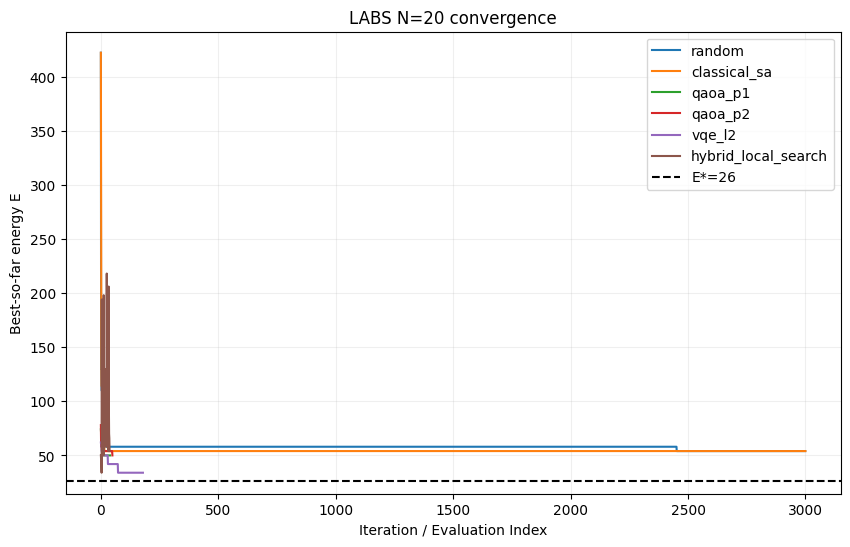

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(random_result["curve"], label="random")
plt.plot(sa_result["curve"], label="classical_sa")
plt.plot(qaoa_p1.curve, label=qaoa_p1.method)
plt.plot(qaoa_p2.curve, label=qaoa_p2.method)
plt.plot(vqe_l2.curve, label=vqe_l2.method)
plt.plot(hybrid_result["curve"], label="hybrid_local_search")

plt.axhline(y=KNOWN_OPTIMUM_E_N20, color="black", linestyle="--", label="E*=26")
plt.xlabel("Iteration / Evaluation Index")
plt.ylabel("Best-so-far energy E")
plt.title("LABS N=20 convergence")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 7) Package Final Solution Cell

Clean final result dictionary for report export.

In [11]:
final_report = {
    "seed": SEED,
    "N": N,
    "verification": verification,
    "comparison": rows_sorted,
    "best_method": rows_sorted[0],
}

final_report

{'seed': 0,
 'N': 20,
 'verification': {'sequence': '+++---+--+-',
  'N': 11,
  'autocorrelations': [0, -1, 0, -1, 0, -1, 0, -1, 0, -1],
  'energy': 5,
  'merit_factor': 12.1,
  'matches_expected': np.True_},
 'comparison': [{'method': 'vqe_l2',
   'best_sequence': '++-++-++++-+-+---+++',
   'E_best': 34,
   'F_best': 5.882352941176471,
   'r': 0.7647058823529411,
   'N_eval': 14400},
  {'method': 'quantum_seeded_local_search',
   'best_sequence': '++-++-++++-+-+---+++',
   'E_best': 34,
   'F_best': 5.882352941176471,
   'r': 0.7647058823529411,
   'N_eval': 38},
  {'method': 'qaoa_p1',
   'best_sequence': '-++++----+--++--+-+-',
   'E_best': 50,
   'F_best': 4.0,
   'r': 0.52,
   'N_eval': 4000},
  {'method': 'qaoa_p2',
   'best_sequence': '++++---+-+-++-++-+++',
   'E_best': 50,
   'F_best': 4.0,
   'r': 0.52,
   'N_eval': 5000},
  {'method': 'random',
   'best_sequence': '-+-++-+-+---+-----++',
   'E_best': 54,
   'F_best': 3.7037037037037037,
   'r': 0.48148148148148145,
   'N_eva